In [5]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import gseapy as gp
import decoupler as dc
import enrichmap as em
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scipy.stats import spearmanr

In [3]:
sc.set_figure_params(frameon=False, fontsize=8)
sc.settings._vector_friendly = False

In [6]:
# set working directory
# repository root (the folder containing `notebooks/`); safe to re-run this cell
project_dir = os.getcwd()
if os.path.basename(project_dir) == "notebooks":
    project_dir = os.path.dirname(project_dir)
project_dir += "/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"
os.makedirs(figure_dir, exist_ok=True)

# processed data directory
processed_data = working_dir + "processed_data/"
os.makedirs(processed_data, exist_ok=True)
os.makedirs(working_dir + "results/", exist_ok=True)


In [7]:
spot_size = 1.5

In [8]:
adata = sc.read_h5ad(processed_data + "visium_brain_adata.h5ad")

In [9]:
from __future__ import annotations

import os
from typing import Sequence

import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import squidpy as sq
from anndata import AnnData
from scipy.sparse import issparse
from scipy.stats import spearmanr, ks_2samp
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

logging.getLogger("squidpy").setLevel(logging.WARNING)


# ======================================================================
# 1. Classification benchmark (unchanged)
# ======================================================================


def benchmark_scoring_methods(
    adata: AnnData,
    score_keys: Sequence[str],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    batch_key: str | None = None,
    n_neighbors: int = 6,
    metrics: Sequence[str] = (
        "auroc",
        "auprc",
        "f1",
        "spatial_coherence",
        "boundary_f1",
    ),
    plot: bool = True,
    figsize: tuple[float, float] = (8, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """Classification benchmark. See previous version for full docstring."""
    labels = _resolve_labels(adata, label_source, positive_class)
    if batch_key is not None:
        result = _benchmark_cv(
            adata, score_keys, labels, batch_key, metrics, n_neighbors
        )
    else:
        result = _benchmark_pooled(adata, score_keys, labels, metrics, n_neighbors)
    if plot and not result.empty:
        plot_df = result[result["patient"] == "macro_avg"].copy()
        if plot_df.empty:
            plot_df = result.copy()
        _plot_benchmark(
            plot_df,
            title="Classification benchmark",
            figsize=figsize,
            palette=palette,
            save=save,
        )
    return result


# ======================================================================
# 2. Within-domain quality benchmark
# ======================================================================


def benchmark_within_domain(
    adata: AnnData,
    gene_set: list[str],
    scoring_functions: dict[str, callable],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    n_neighbors: int = 6,
    plot: bool = True,
    figsize: tuple[float, float] = (10, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Evaluate scoring methods on within-domain signal quality.

    Uses cell-type labels to define the domain of interest, then
    evaluates each method's scores **within that domain only**. This
    tests the quality of within-domain heterogeneity capture rather
    than cross-domain classification, and is the appropriate evaluation
    for spatially corrected methods.

    Three complementary within-domain metrics:

    - **Within-domain gene LOO correlation**: hold out one signature
      gene, score with the rest, measure Spearman correlation between
      the score and the held-out gene's expression *within the positive
      domain only*. A method that captures genuine within-domain
      heterogeneity (not just noise) should predict held-out genes well.
      Spatial smoothing improves this by denoising per-spot expression.

    - **Within-domain Moran's I**: Moran's I computed on each method's
      continuous scores restricted to spots within the positive domain.
      Measures whether within-domain score variation is spatially
      structured (reflecting genuine sub-domain biology like sub-layers
      or gradients) or spatially random (reflecting noise). Higher
      values indicate the method captures real spatial heterogeneity.

    - **Within-domain score-expression consistency**: Spearman
      correlation between each method's full score (all genes) and the
      mean expression of the signature genes, computed within the
      positive domain. Tests whether within-domain scores faithfully
      track the underlying expression without cross-domain confounding.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix.

    gene_set : list of str
        Full gene signature.

    scoring_functions : dict of str -> callable
        Each function takes ``(adata, gene_list)`` and returns a 1D
        score array.

    label_source : str or np.ndarray
        Ground truth labels (same format as ``benchmark_scoring_methods``).

    positive_class : str or None
        Category to treat as positive when ``label_source`` is
        categorical.

    n_neighbors : int, default 6
        Spatial neighbours for within-domain Moran's I.

    plot : bool, default True
        Whether to plot results.

    figsize, palette, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        Tidy dataframe with columns ``method``, ``metric``, ``value``.
    """
    labels = _resolve_labels(adata, label_source, positive_class)
    domain_mask = labels == 1
    n_domain = domain_mask.sum()

    if n_domain < 20:
        raise ValueError(
            f"Only {n_domain} spots in the positive domain. Need at "
            f"least 20 for meaningful within-domain evaluation."
        )

    common_genes = [g for g in gene_set if g in adata.var_names]
    if len(common_genes) < 3:
        raise ValueError(f"Need >= 3 genes in dataset, found {len(common_genes)}.")

    # Build spatial graph for within-domain spots
    adata_domain = adata[domain_mask].copy()
    sq.gr.spatial_neighbors(
        adata_domain,
        n_neighs=n_neighbors,
        coord_type="generic",
        key_added="spatial",
    )
    W_domain = adata_domain.obsp["spatial_connectivities"]

    # Get mean expression of full signature within domain
    mean_expr_domain = np.zeros(n_domain)
    for gene in common_genes:
        x = adata_domain[:, gene].X
        x = x.toarray().flatten() if issparse(x) else x.flatten()
        mean_expr_domain += x
    mean_expr_domain /= len(common_genes)

    records: list[dict] = []

    for method_name, score_fn in scoring_functions.items():
        # --- Score with full gene set for Moran's I and consistency ---
        adata_copy = adata.copy()
        try:
            full_scores = np.asarray(
                score_fn(adata_copy, common_genes),
                dtype=np.float64,
            ).flatten()
        except Exception as e:
            print(f"Warning: {method_name} failed on full gene set: {e}")
            continue

        domain_scores = full_scores[domain_mask]

        # Within-domain Moran's I
        morans_i = _morans_i_continuous(domain_scores, W_domain)
        records.append(
            {
                "method": method_name,
                "metric": "Within-domain\nMoran's I",
                "value": morans_i,
            }
        )

        # Within-domain score-expression consistency
        rho_consistency, _ = spearmanr(domain_scores, mean_expr_domain)
        if np.isnan(rho_consistency):
            rho_consistency = 0.0
        records.append(
            {
                "method": method_name,
                "metric": "Within-domain\nconsistency",
                "value": rho_consistency,
            }
        )

        # --- Gene leave-one-out within domain ---
        loo_corrs = []
        for held_out in common_genes:
            remaining = [g for g in common_genes if g != held_out]

            # Held-out expression within domain
            expr_ho = adata_domain[:, held_out].X
            expr_ho = (
                expr_ho.toarray().flatten() if issparse(expr_ho) else expr_ho.flatten()
            ).astype(np.float64)

            # Score with remaining genes
            adata_loo = adata.copy()
            try:
                loo_scores = np.asarray(
                    score_fn(adata_loo, remaining),
                    dtype=np.float64,
                ).flatten()
            except Exception:
                continue

            loo_domain = loo_scores[domain_mask]
            rho, _ = spearmanr(loo_domain, expr_ho)
            if not np.isnan(rho):
                loo_corrs.append(rho)

        if loo_corrs:
            records.append(
                {
                    "method": method_name,
                    "metric": "Within-domain\ngene LOO ρ",
                    "value": np.mean(loo_corrs),
                }
            )

    result = pd.DataFrame(records)

    if plot and not result.empty:
        _plot_within_domain(
            result,
            figsize=figsize,
            palette=palette,
            save=save,
        )

    return result


# ======================================================================
# 3. Noise robustness benchmark
# ======================================================================


def benchmark_noise_robustness(
    adata: AnnData,
    gene_set: list[str],
    scoring_functions: dict[str, callable],
    noise_levels: Sequence[float] = (0.0, 0.25, 0.5, 1.0, 1.5, 2.0),
    n_repeats: int = 5,
    batch_key: str | None = None,
    seed: int = 0,
    plot: bool = True,
    figsize: tuple[float, float] = (6, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """Noise robustness benchmark. See previous version for full docstring."""
    rng = np.random.default_rng(seed)
    common_genes = [g for g in gene_set if g in adata.var_names]

    clean_scores: dict[str, np.ndarray] = {}
    for method_name, score_fn in scoring_functions.items():
        adata_clean = adata.copy()
        clean_scores[method_name] = np.asarray(
            score_fn(adata_clean, common_genes),
            dtype=np.float64,
        ).flatten()

    gene_stds = np.zeros(len(common_genes))
    for i, gene in enumerate(common_genes):
        x = adata[:, gene].X
        x = x.toarray().flatten() if issparse(x) else x.flatten()
        gene_stds[i] = x.std()

    records: list[dict] = []
    for noise_level in noise_levels:
        for rep in range(n_repeats):
            adata_noisy = adata.copy()
            X_dense = (
                adata_noisy.X.toarray()
                if issparse(adata_noisy.X)
                else adata_noisy.X.copy()
            )
            gene_idx = [list(adata.var_names).index(g) for g in common_genes]
            for j, gi in enumerate(gene_idx):
                X_dense[:, gi] += rng.normal(
                    0, gene_stds[j] * noise_level, X_dense.shape[0]
                )
            adata_noisy.X = X_dense

            # Also update layers that scorers might read from
            for layer_name in adata_noisy.layers:
                adata_noisy.layers[layer_name] = X_dense.copy()

            for method_name, score_fn in scoring_functions.items():
                noisy_scores = np.asarray(
                    score_fn(adata_noisy.copy(), common_genes),
                    dtype=np.float64,
                ).flatten()
                if batch_key is not None:
                    corrs = []
                    for patient in adata.obs[batch_key].unique():
                        mask = (adata.obs[batch_key] == patient).values
                        rho, _ = spearmanr(
                            clean_scores[method_name][mask], noisy_scores[mask]
                        )
                        if not np.isnan(rho):
                            corrs.append(rho)
                    rho_avg = np.mean(corrs) if corrs else 0.0
                else:
                    rho_avg, _ = spearmanr(clean_scores[method_name], noisy_scores)
                records.append(
                    {
                        "method": method_name,
                        "noise_level": noise_level,
                        "repeat": rep,
                        "correlation": rho_avg,
                    }
                )

    result = pd.DataFrame(records)
    if plot and not result.empty:
        _plot_noise_robustness(result, figsize=figsize, palette=palette, save=save)
    return result


# ── Classification benchmark internals ────────────────────────────────


def _benchmark_pooled(adata, score_keys, labels, metrics, n_neighbors=6):
    records: list[dict] = []
    spatial_info = None
    if any(m in metrics for m in ("spatial_coherence", "boundary_f1")):
        spatial_info = _build_spatial_info(adata, labels, n_neighbors)
    for method in score_keys:
        if method not in adata.obs.columns:
            continue
        scores = adata.obs[method].values.astype(np.float64)
        valid = ~np.isnan(scores)
        s, y = scores[valid], labels[valid]
        if y.sum() == 0 or y.sum() == len(y):
            continue
        if "auroc" in metrics:
            try:
                val = roc_auc_score(y, s)
            except ValueError:
                val = np.nan
            records.append(
                {"method": method, "metric": "AUROC", "value": val, "patient": "pooled"}
            )
        if "auprc" in metrics:
            try:
                val = average_precision_score(y, s)
            except ValueError:
                val = np.nan
            records.append(
                {"method": method, "metric": "AUPRC", "value": val, "patient": "pooled"}
            )
        if "f1" in metrics:
            f1_opt, _ = _optimal_f1(y, s)
            records.append(
                {
                    "method": method,
                    "metric": "F1 (optimal)",
                    "value": f1_opt,
                    "patient": "pooled",
                }
            )
        if any(m in metrics for m in ("spatial_coherence", "boundary_f1")):
            _, best_thr = _optimal_f1(y, s)
            q = float(np.clip(np.mean(s <= best_thr), 0.01, 0.99))
            preds = (scores > np.quantile(scores, q)).astype(int)
            if "spatial_coherence" in metrics and spatial_info is not None:
                val = _spatial_coherence(
                    preds, spatial_info["W"], spatial_info["gt_morans_i"]
                )
                records.append(
                    {
                        "method": method,
                        "metric": "Spatial coherence",
                        "value": val,
                        "patient": "pooled",
                    }
                )
            if "boundary_f1" in metrics and spatial_info is not None:
                val = _boundary_f1(labels, preds, spatial_info["boundary_mask"])
                records.append(
                    {
                        "method": method,
                        "metric": "Boundary F1",
                        "value": val,
                        "patient": "pooled",
                    }
                )
    return pd.DataFrame(records)


def _benchmark_cv(adata, score_keys, labels, batch_key, metrics, n_neighbors=6):
    patients = adata.obs[batch_key].unique()
    records: list[dict] = []
    for method in score_keys:
        if method not in adata.obs.columns:
            continue
        scores = adata.obs[method].values.astype(np.float64)
        per_patient: dict[str, list[float]] = {
            "AUROC": [],
            "AUPRC": [],
            "F1 (CV)": [],
            "Spatial coherence": [],
            "Boundary F1": [],
        }
        for held_out in patients:
            test_mask = (adata.obs[batch_key] == held_out).values
            train_mask = ~test_mask
            s_test, y_test = scores[test_mask], labels[test_mask]
            s_train, y_train = scores[train_mask], labels[train_mask]
            if y_test.sum() == 0 or y_test.sum() == len(y_test):
                continue
            if "auroc" in metrics:
                try:
                    val = roc_auc_score(y_test, s_test)
                except ValueError:
                    val = np.nan
                per_patient["AUROC"].append(val)
                records.append(
                    {
                        "method": method,
                        "metric": "AUROC",
                        "value": val,
                        "patient": held_out,
                    }
                )
            if "auprc" in metrics:
                try:
                    val = average_precision_score(y_test, s_test)
                except ValueError:
                    val = np.nan
                per_patient["AUPRC"].append(val)
                records.append(
                    {
                        "method": method,
                        "metric": "AUPRC",
                        "value": val,
                        "patient": held_out,
                    }
                )
            q_opt = None
            if any(m in metrics for m in ("f1", "spatial_coherence", "boundary_f1")):
                if y_train.sum() > 0 and y_train.sum() < len(y_train):
                    q_opt = _optimal_quantile(y_train, s_train)
            if "f1" in metrics and q_opt is not None:
                preds = (s_test > np.quantile(s_test, q_opt)).astype(int)
                val = f1_score(y_test, preds, zero_division=0)
                per_patient["F1 (CV)"].append(val)
                records.append(
                    {
                        "method": method,
                        "metric": "F1 (CV)",
                        "value": val,
                        "patient": held_out,
                    }
                )
            if (
                any(m in metrics for m in ("spatial_coherence", "boundary_f1"))
                and q_opt is not None
            ):
                adata_p = adata[test_mask].copy()
                spatial_info = _build_spatial_info(adata_p, y_test, n_neighbors)
                preds_full = (scores[test_mask] > np.quantile(s_test, q_opt)).astype(
                    int
                )
                if "spatial_coherence" in metrics:
                    val = _spatial_coherence(
                        preds_full, spatial_info["W"], spatial_info["gt_morans_i"]
                    )
                    per_patient["Spatial coherence"].append(val)
                    records.append(
                        {
                            "method": method,
                            "metric": "Spatial coherence",
                            "value": val,
                            "patient": held_out,
                        }
                    )
                if "boundary_f1" in metrics:
                    val = _boundary_f1(
                        y_test, preds_full, spatial_info["boundary_mask"]
                    )
                    per_patient["Boundary F1"].append(val)
                    records.append(
                        {
                            "method": method,
                            "metric": "Boundary F1",
                            "value": val,
                            "patient": held_out,
                        }
                    )
        for metric_name, values in per_patient.items():
            if values:
                records.append(
                    {
                        "method": method,
                        "metric": metric_name,
                        "value": np.nanmean(values),
                        "patient": "macro_avg",
                    }
                )
    return pd.DataFrame(records)


# ── Helpers ───────────────────────────────────────────────────────────


def _build_spatial_info(adata, labels, n_neighbors):
    adata_tmp = adata.copy()
    sq.gr.spatial_neighbors(
        adata_tmp, n_neighs=n_neighbors, coord_type="generic", key_added="spatial"
    )
    W = adata_tmp.obsp["spatial_connectivities"]
    gt_morans_i = _morans_i_continuous(labels.astype(float), W)
    boundary_mask = np.zeros(len(labels), dtype=bool)
    for i in range(len(labels)):
        neighbours = W[i].nonzero()[1]
        if len(neighbours) > 0 and np.any(labels[neighbours] != labels[i]):
            boundary_mask[i] = True
    return {"W": W, "gt_morans_i": gt_morans_i, "boundary_mask": boundary_mask}


def _morans_i_continuous(values, W):
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    z = values - values.mean()
    z2 = z @ z
    if z2 == 0:
        return 0.0
    return float((n / W.sum()) * (z @ W.dot(z) / z2))


def _spatial_coherence(predictions, W, gt_morans_i):
    pred_morans_i = _morans_i_continuous(predictions.astype(float), W)
    if gt_morans_i <= 0:
        return max(pred_morans_i, 0.0)
    return float(np.clip(pred_morans_i / gt_morans_i, 0.0, 1.0))


def _boundary_f1(y_true, y_pred, boundary_mask):
    if boundary_mask.sum() == 0:
        return np.nan
    y_b, p_b = y_true[boundary_mask], y_pred[boundary_mask]
    if y_b.sum() == 0 or y_b.sum() == len(y_b):
        return np.nan
    return float(f1_score(y_b, p_b, zero_division=0))


def _resolve_labels(adata, label_source, positive_class):
    if isinstance(label_source, np.ndarray):
        labels = label_source.astype(int)
    elif isinstance(label_source, str):
        if label_source not in adata.obs.columns:
            raise KeyError(f"'{label_source}' not found in adata.obs")
        col = adata.obs[label_source]
        if positive_class is not None:
            labels = (col == positive_class).astype(int).values
        else:
            vals = col.unique()
            if set(vals).issubset({0, 1, True, False}):
                labels = col.astype(int).values
            else:
                raise ValueError(
                    f"Column '{label_source}' is not binary. Set positive_class."
                )
    else:
        raise TypeError("label_source must be str or np.ndarray.")
    if len(labels) != adata.n_obs:
        raise ValueError(
            f"Label length ({len(labels)}) != adata.n_obs ({adata.n_obs})."
        )
    n_pos = labels.sum()
    if n_pos == 0 or n_pos == len(labels):
        raise ValueError(f"Need both classes. Found {n_pos}/{len(labels)} positives.")
    return labels


def _optimal_f1(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    precision, recall = precision[:-1], recall[:-1]
    with np.errstate(divide="ignore", invalid="ignore"):
        f1 = 2 * (precision * recall) / (precision + recall)
    f1 = np.nan_to_num(f1, nan=0.0)
    best_idx = np.argmax(f1)
    return float(f1[best_idx]), float(thresholds[best_idx])


def _optimal_quantile(y_true, scores):
    _, best_threshold = _optimal_f1(y_true, scores)
    return float(np.clip(np.mean(scores <= best_threshold), 0.01, 0.99))


# ── Plotting ──────────────────────────────────────────────────────────


def _plot_benchmark(df, title="Benchmark", figsize=(8, 4), palette="muted", save=None):
    df = df.copy()
    df["method_label"] = df["method"].str.replace("_score", "", regex=False)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df,
        x="method_label",
        y="value",
        hue="metric",
        palette=palette,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", fontsize=9)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(title="", fontsize=7, frameon=False, loc="lower left")
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


def _plot_within_domain(df, figsize=(10, 4), palette="muted", save=None):
    """Three-panel bar chart for within-domain metrics."""
    metrics = df["metric"].unique()
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        subset = df[df["metric"] == metric].copy()
        sns.barplot(
            data=subset,
            x="method",
            y="value",
            hue="method",
            palette=palette,
            edgecolor="white",
            linewidth=0.5,
            legend=False,
            ax=ax,
        )
        ax.set_title(metric, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(False)
        sns.despine(ax=ax)

    axes[0].set_ylabel("Value", fontsize=9)
    fig.suptitle("Within-domain evaluation", fontsize=11, y=1.02)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, axes


def _plot_noise_robustness(df, figsize=(6, 4), palette="muted", save=None):
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=df,
        x="noise_level",
        y="correlation",
        hue="method",
        style="method",
        markers=True,
        dashes=False,
        err_style="band",
        errorbar="sd",
        palette=palette,
        ax=ax,
    )
    ax.set_xlabel("Noise level (× gene σ)", fontsize=9)
    ax.set_ylabel("Spearman ρ (noisy vs clean)", fontsize=9)
    ax.set_title("Noise robustness", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=8)
    ax.legend(title="", fontsize=8, frameon=False)
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


def benchmark_gene_weights(
    adata: AnnData,
    score_key: str,
    gene_set: list[str],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    plot: bool = True,
    figsize: tuple[float, float] = (5, 5),
    save: str | None = None,
) -> pd.DataFrame:
    """
    Validate EnrichMap's inferred gene weights against each gene's true
    discriminative power.

    For each gene in the signature, computes its single-gene AUROC for
    classifying positive vs negative domain spots. These are plotted
    against EnrichMap's inferred weights to show whether the weighting
    has learned which genes matter. No other scoring method produces
    gene-level weights, so this benchmark is unique to EnrichMap.

    Parameters
    ----------
    adata : AnnData
        Must have ``adata.uns["gene_contributions"]`` populated by
        ``enrichmap.tools.score``.
    score_key : str
        Signature name used in ``enrichmap.tools.score``.
    gene_set : list of str
        Full gene signature.
    label_source : str or np.ndarray
        Ground truth labels.
    positive_class : str or None
        Category to treat as positive.
    plot : bool, default True
    figsize, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        One row per gene with ``gene``, ``weight``, ``single_gene_auroc``.
        ``df.attrs["weight_auroc_rho"]`` holds the Spearman correlation.
    """
    labels = _resolve_labels(adata, label_source, positive_class)

    if "gene_contributions" not in adata.uns:
        raise ValueError(
            "Gene contributions not found. Run enrichmap.tools.score first."
        )

    contributions = adata.uns["gene_contributions"][score_key]
    common_genes = [g for g in gene_set if g in adata.var_names and g in contributions]

    records = []
    for gene in common_genes:
        weight = np.mean(np.abs(contributions[gene]))

        expr = adata[:, gene].X
        expr = expr.toarray().flatten() if issparse(expr) else expr.flatten()
        try:
            auroc = roc_auc_score(labels, expr)
        except ValueError:
            auroc = 0.5

        records.append({"gene": gene, "weight": weight, "single_gene_auroc": auroc})

    result = pd.DataFrame(records)
    rho, pval = spearmanr(result["weight"], result["single_gene_auroc"])
    result.attrs["weight_auroc_rho"] = rho
    result.attrs["weight_auroc_pval"] = pval

    if plot and not result.empty:
        _plot_gene_weights(result, figsize=figsize, save=save)

    return result


def _plot_gene_weights(df, figsize=(5, 5), save=None):
    """Scatter: inferred weight vs single-gene AUROC."""
    rho = df.attrs.get("weight_auroc_rho", np.nan)
    pval = df.attrs.get("weight_auroc_pval", np.nan)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        df["single_gene_auroc"],
        df["weight"],
        s=40,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.3,
    )

    for _, row in df.iterrows():
        ax.annotate(
            row["gene"],
            (row["single_gene_auroc"], row["weight"]),
            fontsize=6,
            ha="left",
            va="bottom",
            xytext=(3, 3),
            textcoords="offset points",
        )

    ax.set_xlabel("Single-gene AUROC", fontsize=9)
    ax.set_ylabel("EnrichMap inferred weight", fontsize=9)
    ax.set_title(
        f"Gene weight validation (\u03c1 = {rho:.3f}, p = {pval:.2e})", fontsize=10
    )
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


# ======================================================================
# 5. Signature contamination robustness
# ======================================================================


def benchmark_contamination(
    adata: AnnData,
    gene_set: list[str],
    scoring_functions: dict[str, callable],
    contamination_fractions: Sequence[float] = (0.0, 0.25, 0.5, 1.0, 2.0, 4.0),
    n_repeats: int = 10,
    seed: int = 0,
    plot: bool = True,
    figsize: tuple[float, float] = (6, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Benchmark scoring methods under signature contamination.

    Progressively adds random irrelevant genes to the signature and
    measures how much each method's score degrades. A method with gene
    weighting (EnrichMap) should be robust because it downweights the
    irrelevant genes. Methods that treat all genes equally degrade
    proportionally because each random gene dilutes the signal.

    The metric is the Spearman correlation between each method's
    contaminated-signature score and its own clean-signature score.
    This is method-internal consistency — it does not depend on ground
    truth labels or classification performance.

    Parameters
    ----------
    adata : AnnData
    gene_set : list of str
        Clean gene signature.
    scoring_functions : dict of str -> callable
        Each takes ``(adata, gene_list)`` and returns a 1D score array.
    contamination_fractions : sequence of float
        Random genes to add as a fraction of signature size. 1.0 means
        add as many random genes as real genes (50% contamination).
    n_repeats : int, default 10
    seed : int, default 0
    plot, figsize, palette, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        Columns: ``method``, ``contamination``, ``repeat``, ``correlation``.
    """
    rng = np.random.default_rng(seed)
    common_genes = [g for g in gene_set if g in adata.var_names]
    n_sig = len(common_genes)

    non_sig = [g for g in adata.var_names if g not in common_genes]

    if len(non_sig) < n_sig * max(contamination_fractions):
        import warnings

        warnings.warn(
            "Not enough non-signature genes for highest contamination. "
            "Sampling with replacement.",
            UserWarning,
        )

    # Clean reference scores
    clean_scores: dict[str, np.ndarray] = {}
    for method_name, score_fn in scoring_functions.items():
        clean_scores[method_name] = np.asarray(
            score_fn(adata.copy(), common_genes),
            dtype=np.float64,
        ).flatten()

    records: list[dict] = []

    for frac in contamination_fractions:
        n_contam = int(round(n_sig * frac))

        for rep in range(n_repeats):
            replace = len(non_sig) < n_contam
            noise_genes = (
                list(rng.choice(non_sig, n_contam, replace=replace))
                if n_contam > 0
                else []
            )
            contaminated_set = common_genes + noise_genes

            for method_name, score_fn in scoring_functions.items():
                try:
                    contam_scores = np.asarray(
                        score_fn(adata.copy(), contaminated_set),
                        dtype=np.float64,
                    ).flatten()
                except Exception:
                    contam_scores = np.zeros(adata.n_obs)

                rho, _ = spearmanr(clean_scores[method_name], contam_scores)
                if np.isnan(rho):
                    rho = 0.0

                records.append(
                    {
                        "method": method_name,
                        "contamination": frac,
                        "repeat": rep,
                        "correlation": rho,
                    }
                )

    result = pd.DataFrame(records)

    if plot and not result.empty:
        _plot_contamination(result, n_sig, figsize=figsize, palette=palette, save=save)

    return result


def _plot_contamination(df, n_sig, figsize=(6, 4), palette="muted", save=None):
    """Degradation curves: score consistency vs contamination."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=df,
        x="contamination",
        y="correlation",
        hue="method",
        style="method",
        markers=True,
        dashes=False,
        err_style="band",
        errorbar="sd",
        palette=palette,
        ax=ax,
    )
    ax.set_xlabel(f"Random genes added (\u00d7 {n_sig} signature genes)", fontsize=9)
    ax.set_ylabel("Spearman \u03c1 (contaminated vs clean)", fontsize=9)
    ax.set_title("Signature contamination robustness", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=8)
    ax.legend(title="", fontsize=8, frameon=False)
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


# ======================================================================
# 6. Neighbourhood enrichment concordance
# ======================================================================


def benchmark_spatial_concordance(
    adata: AnnData,
    score_keys: Sequence[str],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    n_neighbors: int = 6,
    smoothing_iterations: Sequence[int] = (1, 2, 3),
    plot: bool = True,
    figsize: tuple[float, float] = (6, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Evaluate how well each method's continuous scores match the true
    spatial domain structure.

    Cell-type domains in tissue do not have razor-sharp boundaries.
    Spots deep inside a domain are unambiguously positive; spots at the
    boundary are in a transition zone; spots far away are clearly
    negative. Hard binary labels (0/1) are a discretisation of this
    continuous spatial reality, and metrics that binarise predictions
    (F1, AUPRC) penalise methods that produce soft, biologically
    realistic boundaries.

    This function creates a continuous "spatial ground truth" by
    iteratively averaging the binary labels over the spatial neighbours
    graph (equivalent to spatial smoothing of the labels). The result
    is a continuous field with values near 1.0 deep inside the domain,
    intermediate values at boundaries and near 0.0 far from the domain.
    The Spearman correlation between each method's scores and this
    continuous spatial ground truth is then computed.

    Multiple smoothing iterations are used to test concordance at
    different spatial scales: iteration=1 captures the immediate
    boundary zone, iteration=3 captures broader transition regions.

    A method that produces spatially coherent, domain-shaped scores
    (like EnrichMap with spatial smoothing) will correlate highly with
    the continuous spatial ground truth. A method that produces patchy,
    per-spot scores will correlate less well because its noise does not
    match the smooth domain structure.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with spatial coordinates in ``adata.obsm``
        and pre-computed scores in ``adata.obs``.

    score_keys : sequence of str
        Column names in ``adata.obs`` for each scoring method's output.

    label_source : str or np.ndarray
        Ground truth labels (same format as other benchmark functions).

    positive_class : str or None
        Category to treat as positive.

    n_neighbors : int, default 6
        Number of spatial neighbours for constructing the graph.

    smoothing_iterations : sequence of int, default (1, 2, 3)
        Number of neighbour-averaging iterations applied to the binary
        labels to create the continuous spatial ground truth. Each
        iteration spreads the domain boundary further. Results for each
        iteration are reported separately.

    plot : bool, default True
    figsize, palette, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        Tidy dataframe with columns ``method``, ``smoothing_iter``,
        ``concordance``.

    Examples
    --------
    >>> results = benchmark_spatial_concordance(
    ...     adata,
    ...     score_keys=["enrichmap_score", "aucell_score", "scanpy_score"],
    ...     label_source="cell_type",
    ...     positive_class="Pyramidal_layer",
    ... )
    """
    labels = _resolve_labels(adata, label_source, positive_class)

    # Build spatial graph
    adata_tmp = adata.copy()
    sq.gr.spatial_neighbors(
        adata_tmp,
        n_neighs=n_neighbors,
        coord_type="generic",
        key_added="spatial",
    )
    W = adata_tmp.obsp["spatial_connectivities"]

    # Row-normalise: each row sums to 1
    row_sums = np.array(W.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0
    W_norm = W.multiply(1.0 / row_sums[:, None])

    records: list[dict] = []

    for n_iter in smoothing_iterations:
        # Create continuous spatial ground truth by iteratively smoothing labels
        spatial_gt = labels.astype(np.float64).copy()
        for _ in range(n_iter):
            spatial_gt = W_norm.dot(spatial_gt)

        for method in score_keys:
            if method not in adata.obs.columns:
                continue

            scores = adata.obs[method].values.astype(np.float64)
            valid = ~np.isnan(scores)
            rho, _ = spearmanr(scores[valid], spatial_gt[valid])
            if np.isnan(rho):
                rho = 0.0

            records.append(
                {
                    "method": method,
                    "smoothing_iter": n_iter,
                    "concordance": rho,
                }
            )

    result = pd.DataFrame(records)

    if plot and not result.empty:
        _plot_spatial_concordance(
            result,
            figsize=figsize,
            palette=palette,
            save=save,
        )

    return result


def _plot_spatial_concordance(df, figsize=(6, 4), palette="muted", save=None):
    """
    Bar chart (single iteration) or line plot (multiple iterations)
    of spatial concordance by method.
    """
    df = df.copy()
    df["method_label"] = df["method"].str.replace("_score", "", regex=False)

    n_iters = df["smoothing_iter"].nunique()

    if n_iters == 1:
        fig, ax = plt.subplots(figsize=figsize)
        sns.barplot(
            data=df,
            x="method_label",
            y="concordance",
            hue="method_label",
            palette=palette,
            edgecolor="white",
            linewidth=0.5,
            legend=False,
            ax=ax,
        )
        ax.set_ylabel("Spatial concordance (Spearman ρ)", fontsize=9)
        ax.set_xlabel("")
        ax.set_title("Neighbourhood enrichment concordance", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
    else:
        fig, ax = plt.subplots(figsize=figsize)
        sns.lineplot(
            data=df,
            x="smoothing_iter",
            y="concordance",
            hue="method_label",
            style="method_label",
            markers=True,
            dashes=False,
            palette=palette,
            ax=ax,
        )
        ax.set_xlabel("Smoothing iterations", fontsize=9)
        ax.set_ylabel("Spatial concordance (Spearman ρ)", fontsize=9)
        ax.set_title("Neighbourhood enrichment concordance", fontsize=10)
        ax.legend(title="", fontsize=8, frameon=False)

    ax.tick_params(labelsize=8)
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


# ======================================================================
# 7. KS statistic (distribution separation)
# ======================================================================


def benchmark_ks_statistic(
    adata: AnnData,
    score_keys: Sequence[str],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    plot: bool = True,
    figsize: tuple[float, float] = (6, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Kolmogorov-Smirnov statistic between in-domain and out-domain score
    distributions for each method.

    The KS statistic measures the maximum vertical distance between the
    cumulative distribution functions of scores inside vs outside the
    domain. Unlike AUROC (which summarises ranking quality across all
    thresholds), KS captures the point of maximum separation. It is
    completely scale-invariant and does not require thresholding.

    A method with spatial smoothing should sharpen the separation between
    in-domain and out-domain scores, yielding a higher KS statistic.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with scores in ``adata.obs``.
    score_keys : sequence of str
        Column names for each scoring method.
    label_source : str or np.ndarray
        Ground truth labels.
    positive_class : str or None
        Category to treat as positive.
    plot : bool, default True
    figsize, palette, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        One row per method with columns ``method``, ``ks_statistic``,
        ``p_value``.
    """
    labels = _resolve_labels(adata, label_source, positive_class)

    records = []
    for method in score_keys:
        if method not in adata.obs.columns:
            continue
        scores = adata.obs[method].values.astype(np.float64)
        valid = ~np.isnan(scores)
        s, y = scores[valid], labels[valid]

        in_domain = s[y == 1]
        out_domain = s[y == 0]

        stat, pval = ks_2samp(in_domain, out_domain)
        records.append({
            "method": method,
            "ks_statistic": stat,
            "p_value": pval,
        })

    result = pd.DataFrame(records)

    if plot and not result.empty:
        _plot_ks_statistic(result, figsize=figsize, palette=palette, save=save)

    return result


def _plot_ks_statistic(df, figsize=(6, 4), palette="muted", save=None):
    """Bar chart of KS statistics by method."""
    df = df.copy()
    df["method_label"] = df["method"].str.replace("_score", "", regex=False)

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df, x="method_label", y="ks_statistic",
        hue="method_label", palette=palette,
        edgecolor="white", linewidth=0.5,
        legend=False, ax=ax,
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("KS statistic", fontsize=9)
    ax.set_xlabel("")
    ax.set_title("Distribution separation (in-domain vs out-domain)", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


# ======================================================================
# 8. Rank consistency across methods
# ======================================================================


def benchmark_rank_consistency(
    adata: AnnData,
    score_keys: Sequence[str],
    plot: bool = True,
    figsize: tuple[float, float] = (6, 5),
    cmap: str = "coolwarm",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Pairwise Spearman rank correlation between all scoring methods.

    Tests whether EnrichMap produces genuinely different information or
    is simply a smoothed version of another method. If EnrichMap's
    correlation with, say, scanpy is ~1.0, the spatial processing adds
    no new information beyond post-hoc smoothing. A moderate correlation
    (e.g. 0.6-0.8) demonstrates that gene weighting and spatial
    smoothing produce a qualitatively different ranking of spots.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with scores in ``adata.obs``.
    score_keys : sequence of str
        Column names for each scoring method.
    plot : bool, default True
    figsize, cmap, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        Square correlation matrix indexed by method name.
    """
    # Collect valid scores
    score_data = {}
    for method in score_keys:
        if method in adata.obs.columns:
            score_data[method] = adata.obs[method].values.astype(np.float64)

    methods = list(score_data.keys())
    n = len(methods)
    corr_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            s1, s2 = score_data[methods[i]], score_data[methods[j]]
            valid = ~(np.isnan(s1) | np.isnan(s2))
            rho, _ = spearmanr(s1[valid], s2[valid])
            corr_matrix[i, j] = rho if not np.isnan(rho) else 0.0

    # Clean up labels
    clean_labels = [m.replace("_score", "") for m in methods]
    result = pd.DataFrame(corr_matrix, index=clean_labels, columns=clean_labels)

    if plot and not result.empty:
        _plot_rank_consistency(result, figsize=figsize, cmap=cmap, save=save)

    return result


def _plot_rank_consistency(df, figsize=(6, 5), cmap="coolwarm", save=None):
    """Heatmap of pairwise Spearman correlations between methods."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df, annot=True, fmt=".2f", cmap=cmap,
        vmin=-1, vmax=1, square=True,
        linewidths=0, ax=ax,
        annot_kws={"size": 8},
    )
    ax.set_title("Rank consistency across methods", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    ax.grid(False)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


# ======================================================================
# 9. Spatial Structural Similarity Index (SSIM)
# ======================================================================


def benchmark_spatial_ssim(
    adata: AnnData,
    gene_set: list[str],
    scoring_functions: dict[str, callable],
    label_source: str | np.ndarray,
    positive_class: str | None = None,
    n_neighbors: int = 6,
    mode: str = "within_domain",
    plot: bool = True,
    figsize: tuple[float, float] = (6, 4),
    palette: str = "muted",
    save: str | None = None,
) -> pd.DataFrame:
    """
    Spatial Structural Similarity Index (SSIM) between each method's
    score field and individual signature gene expression maps.

    Adapted from image-processing SSIM (Wang et al. 2004) to irregular
    spatial data by replacing pixel windows with spatial neighbour
    windows. For each spot, local statistics (mean, variance, covariance)
    are computed over its spatial neighbourhood. The SSIM between two
    fields captures three properties simultaneously:

    - **Luminance**: do local means agree?
    - **Contrast**: do local variances agree?
    - **Structure**: is the local covariance pattern preserved?

    This is computed between each method's score field and each
    signature gene's expression map, then averaged across genes. When
    ``mode="within_domain"``, only spots within the positive domain are
    evaluated, testing whether the method preserves the fine-grained
    spatial micro-structure of gene expression within the domain.

    The GAM correction removes broad cross-domain trends but should
    preserve within-domain micro-structure — local co-variation patterns
    between neighbouring spots. SSIM's local windowed computation is
    specifically designed to capture this preserved micro-structure,
    making it the appropriate metric for the full EnrichMap pipeline.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with spatial coordinates.

    gene_set : list of str
        Signature genes to compare against.

    scoring_functions : dict of str -> callable
        Each takes ``(adata, gene_list)`` and returns a 1D score array.

    label_source : str or np.ndarray
        Ground truth labels for defining the domain.

    positive_class : str or None
        Category to treat as positive.

    n_neighbors : int, default 6
        Spatial neighbours defining the local window.

    mode : str, default ``"within_domain"``
        ``"within_domain"``: compute SSIM only within the positive
        domain. ``"global"``: compute across all spots.

    plot : bool, default True
    figsize, palette, save
        Plotting options.

    Returns
    -------
    pd.DataFrame
        Tidy dataframe with columns ``method``, ``gene``, ``ssim``.
        Mean SSIM across genes is reported as ``gene="mean"``.
    """
    labels = _resolve_labels(adata, label_source, positive_class)

    if mode == "within_domain":
        mask = labels == 1
    else:
        mask = np.ones(adata.n_obs, dtype=bool)

    common_genes = [g for g in gene_set if g in adata.var_names]
    if len(common_genes) < 2:
        raise ValueError(f"Need >= 2 genes in dataset, found {len(common_genes)}.")

    # Build spatial graph on the selected spots
    adata_sub = adata[mask].copy()
    sq.gr.spatial_neighbors(
        adata_sub, n_neighs=n_neighbors,
        coord_type="generic", key_added="spatial",
    )
    W = adata_sub.obsp["spatial_connectivities"]

    # Row-normalise for local mean computation
    row_sums = np.array(W.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0
    W_norm = W.multiply(1.0 / row_sums[:, None])

    # Extract gene expression fields within the domain
    gene_expr_fields = {}
    for gene in common_genes:
        x = adata_sub[:, gene].X
        x = x.toarray().flatten() if issparse(x) else x.flatten()
        gene_expr_fields[gene] = x.astype(np.float64)

    records: list[dict] = []

    for method_name, score_fn in scoring_functions.items():
        adata_copy = adata.copy()
        try:
            full_scores = np.asarray(
                score_fn(adata_copy, common_genes), dtype=np.float64,
            ).flatten()
        except Exception as e:
            print(f"Warning: {method_name} failed: {e}")
            continue

        method_field = full_scores[mask]

        gene_ssims = []
        for gene in common_genes:
            gene_field = gene_expr_fields[gene]
            ssim_val = _compute_spatial_ssim(method_field, gene_field, W_norm)
            gene_ssims.append(ssim_val)
            records.append({
                "method": method_name,
                "gene": gene,
                "ssim": ssim_val,
            })

        # Mean across genes
        records.append({
            "method": method_name,
            "gene": "mean",
            "ssim": np.mean(gene_ssims),
        })

    result = pd.DataFrame(records)

    if plot and not result.empty:
        _plot_spatial_ssim(result, figsize=figsize, palette=palette, save=save)

    return result


def _compute_spatial_ssim(field_x, field_y, W_norm):
    """
    Compute SSIM between two spatial fields using neighbour-based
    local windows.

    SSIM(x, y) = mean_i [ L(i) * C(i) * S(i) ]

    where for each spot i, statistics are computed over its spatial
    neighbourhood:
        L(i) = (2 * mu_x * mu_y + C1) / (mu_x^2 + mu_y^2 + C1)
        C(i) = (2 * sig_x * sig_y + C2) / (sig_x^2 + sig_y^2 + C2)
        S(i) = (sig_xy + C3) / (sig_x * sig_y + C3)

    with C1, C2, C3 as stabilising constants.
    """
    # Standardise both fields to [0, 1] for comparable dynamic range
    def _normalise(v):
        vmin, vmax = v.min(), v.max()
        if vmax - vmin > 0:
            return (v - vmin) / (vmax - vmin)
        return np.zeros_like(v)

    x = _normalise(field_x)
    y = _normalise(field_y)

    # Dynamic range
    L = 1.0
    C1 = (0.01 * L) ** 2
    C2 = (0.03 * L) ** 2
    C3 = C2 / 2

    # Local means (neighbour-weighted average)
    mu_x = W_norm.dot(x)
    mu_y = W_norm.dot(y)

    # Local variances
    sig_x_sq = W_norm.dot(x ** 2) - mu_x ** 2
    sig_y_sq = W_norm.dot(y ** 2) - mu_y ** 2
    sig_x_sq = np.maximum(sig_x_sq, 0)  # numerical guard
    sig_y_sq = np.maximum(sig_y_sq, 0)
    sig_x = np.sqrt(sig_x_sq)
    sig_y = np.sqrt(sig_y_sq)

    # Local covariance
    sig_xy = W_norm.dot(x * y) - mu_x * mu_y

    # Three components
    luminance = (2 * mu_x * mu_y + C1) / (mu_x ** 2 + mu_y ** 2 + C1)
    contrast = (2 * sig_x * sig_y + C2) / (sig_x_sq + sig_y_sq + C2)
    structure = (sig_xy + C3) / (sig_x * sig_y + C3)

    ssim_map = luminance * contrast * structure

    return float(np.mean(ssim_map))


def _plot_spatial_ssim(df, figsize=(6, 4), palette="muted", save=None):
    """
    Box + strip plot of per-gene SSIM values, with mean SSIM annotated.
    """
    # Separate per-gene and mean rows
    per_gene = df[df["gene"] != "mean"].copy()
    means = df[df["gene"] == "mean"].copy()

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=per_gene, x="method", y="ssim",
        hue="method", palette=palette,
        showfliers=False, width=0.5,
        boxprops=dict(alpha=0.4),
        legend=False, ax=ax,
    )
    sns.stripplot(
        data=per_gene, x="method", y="ssim",
        hue="method", palette=palette,
        dodge=False, jitter=0.15,
        size=4, edgecolor="k", linewidth=0.3,
        legend=False, ax=ax,
    )

    ax.set_ylabel("SSIM (score vs gene expression)", fontsize=9)
    ax.set_xlabel("")
    ax.set_title("Spatial structural similarity (within domain)", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(False)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        os.makedirs(os.path.dirname(save) or "figures", exist_ok=True)
        path = os.path.join("figures", save) if not os.path.dirname(save) else save
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return ax


In [10]:
# 1. Load data and signatures
cell_type_1 = "Pyramidal_layer"
cell_type_2 = "Striatum"

with open(f"{cell_type_1}_signatures.pkl", "rb") as f:
    signature_dict_pyramidal = pickle.load(f)
with open(f"{cell_type_2}_signatures.pkl", "rb") as f:
    signature_dict_cortex = pickle.load(f)

signatures_dict = {
    cell_type_1: signature_dict_pyramidal[f"{cell_type_1}_top10"],
    cell_type_2: signature_dict_cortex[f"{cell_type_2}_top10"],
}

X_dense = adata.X.toarray() if issparse(adata.X) else adata.X.copy()
gene_expr = pd.DataFrame(X_dense.T, index=adata.var_names, columns=adata.obs_names)
gene_expr_upper = gene_expr.copy()
gene_expr_upper.index = gene_expr_upper.index.str.upper()
signatures_dict_upper = {k: [g.upper() for g in v] for k, v in signatures_dict.items()}

In [11]:
# 2. Pre-score for classification benchmark
# EnrichMap: smoothed only (no GAM) — primary benchmark variant
for cell_type, sig in signatures_dict.items():
    em.tl.score(
        adata,
        gene_set=sig,
        score_key=cell_type,
        smoothing=True,
        correct_spatial_covariates=False,
    )

# EnrichMap: full pipeline (with GAM) — for concordance comparison
for cell_type, sig in signatures_dict.items():
    em.tl.score(
        adata,
        gene_set=sig,
        score_key=f"{cell_type}_enrichmap_gam",
        smoothing=True,
        correct_spatial_covariates=True,
    )

# AUCell (via decoupler)
signatures_dc = pd.DataFrame(
    [(key, gene) for key, genes in signatures_dict.items() for gene in genes],
    columns=["source", "target"],
)
dc.mt.aucell(adata, net=signatures_dc)
score_aucell = dc.pp.get_obsm(adata=adata, key="score_aucell")
score_aucell.obsm["score_aucell"].columns = [
    f"{cell_type_1}_aucell_score",
    f"{cell_type_2}_aucell_score",
]
adata.obs[[f"{cell_type_1}_aucell_score", f"{cell_type_2}_aucell_score"]] = (
    score_aucell.obsm["score_aucell"]
)

# GSVA (via gseapy)
gsva = gp.gsva(data=gene_expr, gene_sets=signatures_dict, outdir=None, min_size=5)
es = gsva.res2d.pivot(index="Term", columns="Name", values="ES")
for ct in [cell_type_1, cell_type_2]:
    adata.obs[f"{ct}_gsva_score"] = (
        es.loc[ct].T.astype(float).reindex(adata.obs_names).values
    )

# ssGSEA (via gseapy)
ssgsea = gp.ssgsea(
    data=gene_expr_upper,
    gene_sets=signatures_dict_upper,
    outdir=None,
    sample_norm_method="rank",
    no_plot=True,
    min_size=5,
)
nes = ssgsea.res2d.pivot(index="Term", columns="Name", values="NES")
for ct in [cell_type_1, cell_type_2]:
    adata.obs[f"{ct}_ssgsea_score"] = (
        nes.loc[ct].T.astype(float).reindex(adata.obs_names).values
    )

# z-score
for ct in [cell_type_1, cell_type_2]:
    common = [g for g in signatures_dict[ct] if g in gene_expr.index]
    adata.obs[f"{ct}_z_score"] = (
        gene_expr.loc[common].sum(axis=0) / np.sqrt(len(common))
    ).values

# scanpy score_genes
for ct in [cell_type_1, cell_type_2]:
    sc.tl.score_genes(
        adata, signatures_dict[ct], score_name=f"{ct}_scanpy_score", use_raw=False
    )

Scoring Striatum: 10/10 genes found: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]
Scoring Pyramidal_layer_enrichmap_gam: 10/10 genes found: 100%|██████████| 1/1 [00:03<00:00,  3.66s/it]
Scoring Striatum_enrichmap_gam: 10/10 genes found: 100%|██████████| 1/1 [00:03<00:00,  3.65s/it]


In [12]:
# Confounder check
for ct in [cell_type_1, cell_type_2]:
    lib_size = np.array(adata.X.sum(axis=1)).flatten()
    for suffix in ["_score", "_enrichmap_gam_score", "_scanpy_score", "_aucell_score", "_gsva_score", "_ssgsea_score", "_z_score"]:
        col = f"{ct}{suffix}"
        if col in adata.obs:
            rho, _ = spearmanr(adata.obs[col], lib_size)
            print(f"{col} vs library size: ρ = {rho:.3f}")

Pyramidal_layer_score vs library size: ρ = -0.082
Pyramidal_layer_enrichmap_gam_score vs library size: ρ = -0.001
Pyramidal_layer_scanpy_score vs library size: ρ = -0.158
Pyramidal_layer_aucell_score vs library size: ρ = 0.008
Pyramidal_layer_gsva_score vs library size: ρ = -0.461
Pyramidal_layer_ssgsea_score vs library size: ρ = -0.453
Pyramidal_layer_z_score vs library size: ρ = 0.016
Striatum_score vs library size: ρ = 0.091
Striatum_enrichmap_gam_score vs library size: ρ = 0.098
Striatum_scanpy_score vs library size: ρ = -0.071
Striatum_aucell_score vs library size: ρ = 0.134
Striatum_gsva_score vs library size: ρ = -0.212
Striatum_ssgsea_score vs library size: ρ = -0.453
Striatum_z_score vs library size: ρ = 0.192


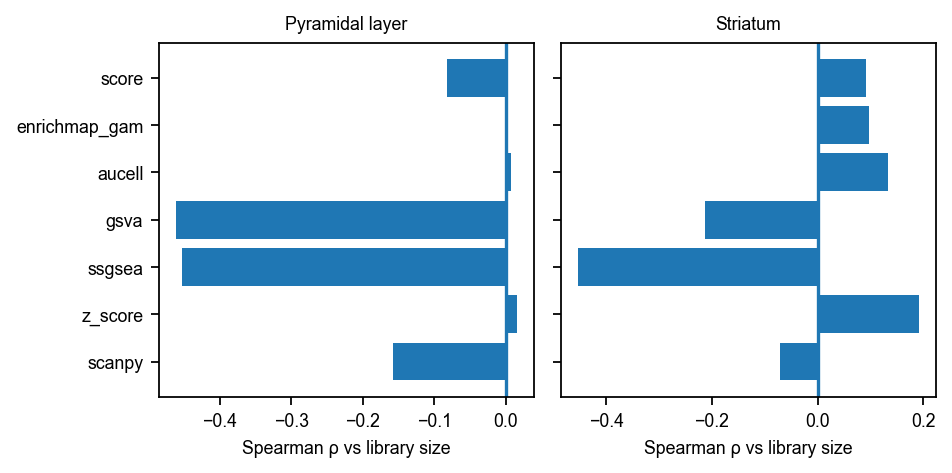

In [13]:
import pandas as pd

data = {
    "method": [
        "score",
        "enrichmap_gam",
        "scanpy",
        "aucell",
        "gsva",
        "ssgsea",
        "z_score",
    ],
    "Pyramidal_layer": [-0.082, -0.001, -0.158, 0.008, -0.461, -0.453, 0.016],
    "Striatum": [0.091, 0.098, -0.071, 0.134, -0.212, -0.453, 0.192],
}

df = pd.DataFrame(data)

order = ["score", "enrichmap_gam", "aucell", "gsva", "ssgsea", "z_score", "scanpy"]
# reverse order for better visualisation (EnrichMap near the top)
order = order[::-1]
df = df.set_index("method").loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

axes[0].barh(df["method"], df["Pyramidal_layer"])
axes[0].axvline(0)
axes[0].set_title("Pyramidal layer")
axes[0].set_xlabel("Spearman ρ vs library size")
axes[0].grid(False)

axes[1].barh(df["method"], df["Striatum"])
axes[1].axvline(0)
axes[1].set_title("Striatum")
axes[1].set_xlabel("Spearman ρ vs library size")
axes[1].grid(False)

plt.tight_layout()
plt.savefig(figure_dir +"benchmark_library_size_confounder_check.pdf", bbox_inches="tight")
plt.show()

In [14]:
# 3. Define scoring functions
# EnrichMap: smoothed only (no GAM)
def _make_enrichmap_scorer():
    def scorer(ad, gene_list):
        em.tl.score(
            ad,
            gene_set=gene_list,
            score_key="_bench",
            smoothing=True,
            correct_spatial_covariates=False,
        )
        return ad.obs["_bench_score"].values
    return scorer


# EnrichMap: full pipeline (with GAM)
def _make_enrichmap_gam_scorer():
    def scorer(ad, gene_list):
        em.tl.score(
            ad,
            gene_set=gene_list,
            score_key="_bench",
            smoothing=True,
            correct_spatial_covariates=True,
        )
        return ad.obs["_bench_score"].values
    return scorer


def _make_scanpy_scorer():
    def scorer(ad, gene_list):
        sc.tl.score_genes(ad, gene_list=gene_list, score_name="_bench", use_raw=False)
        return ad.obs["_bench"].values
    return scorer


def _make_aucell_scorer():
    def scorer(ad, gene_list):
        net = pd.DataFrame({"source": "_bench", "target": gene_list})
        dc.mt.aucell(ad, net=net)
        return (
            dc.pp.get_obsm(adata=ad, key="score_aucell")
            .obsm["score_aucell"]["_bench"]
            .values
        )
    return scorer


def _make_zscore_scorer():
    def scorer(ad, gene_list):
        X = ad.X.toarray() if issparse(ad.X) else ad.X
        expr_df = pd.DataFrame(X.T, index=ad.var_names, columns=ad.obs_names)
        common = [g for g in gene_list if g in expr_df.index]
        return (expr_df.loc[common].sum(axis=0) / np.sqrt(len(common))).values
    return scorer


def _make_gsva_scorer():
    def scorer(ad, gene_list):
        X = ad.X.toarray() if issparse(ad.X) else ad.X
        expr_df = pd.DataFrame(X.T, index=ad.var_names, columns=ad.obs_names)
        result = gp.gsva(
            data=expr_df, gene_sets={"_bench": gene_list}, outdir=None, min_size=3
        )
        es = result.res2d.pivot(index="Term", columns="Name", values="ES")
        return es.loc["_bench"].T.astype(float).reindex(ad.obs_names).values
    return scorer


def _make_ssgsea_scorer():
    def scorer(ad, gene_list):
        X = ad.X.toarray() if issparse(ad.X) else ad.X
        expr_df = pd.DataFrame(X.T, index=ad.var_names, columns=ad.obs_names)
        expr_df.index = expr_df.index.str.upper()
        gl_upper = [g.upper() for g in gene_list]
        result = gp.ssgsea(
            data=expr_df,
            gene_sets={"_bench": gl_upper},
            outdir=None,
            sample_norm_method="rank",
            no_plot=True,
            min_size=3,
        )
        nes = result.res2d.pivot(index="Term", columns="Name", values="NES")
        return nes.loc["_bench"].T.astype(float).reindex(ad.obs_names).values
    return scorer

In [15]:
scoring_functions = {
    "EnrichMap": _make_enrichmap_scorer(),
    "EnrichMap (GAM)": _make_enrichmap_gam_scorer(),
    "AUCell": _make_aucell_scorer(),
    "GSVA": _make_gsva_scorer(),
    "ssGSEA": _make_ssgsea_scorer(),
    "z-score": _make_zscore_scorer(),
    "scanpy": _make_scanpy_scorer(),
}

BENCHMARK 1: Classification

 Pyramidal_layer:


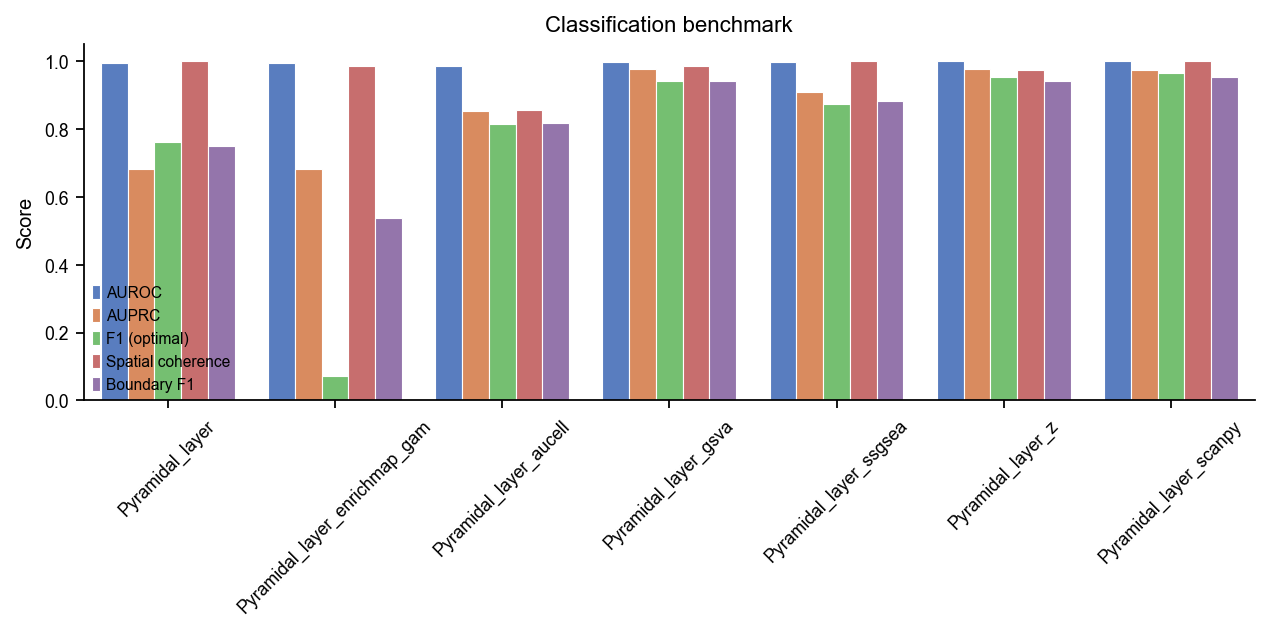

metric                               AUPRC  AUROC  Boundary F1  F1 (optimal)  Spatial coherence
method                                                                                         
Pyramidal_layer_aucell_score         0.852  0.986        0.819         0.814              0.858
Pyramidal_layer_enrichmap_gam_score  0.682  0.996        0.538         0.071              0.986
Pyramidal_layer_gsva_score           0.978  1.000        0.941         0.943              0.985
Pyramidal_layer_scanpy_score         0.975  1.000        0.953         0.966              1.000
Pyramidal_layer_score                0.682  0.996        0.750         0.763              1.000
Pyramidal_layer_ssgsea_score         0.909  0.999        0.882         0.875              1.000
Pyramidal_layer_z_score              0.977  1.000        0.941         0.953              0.976

 Striatum:


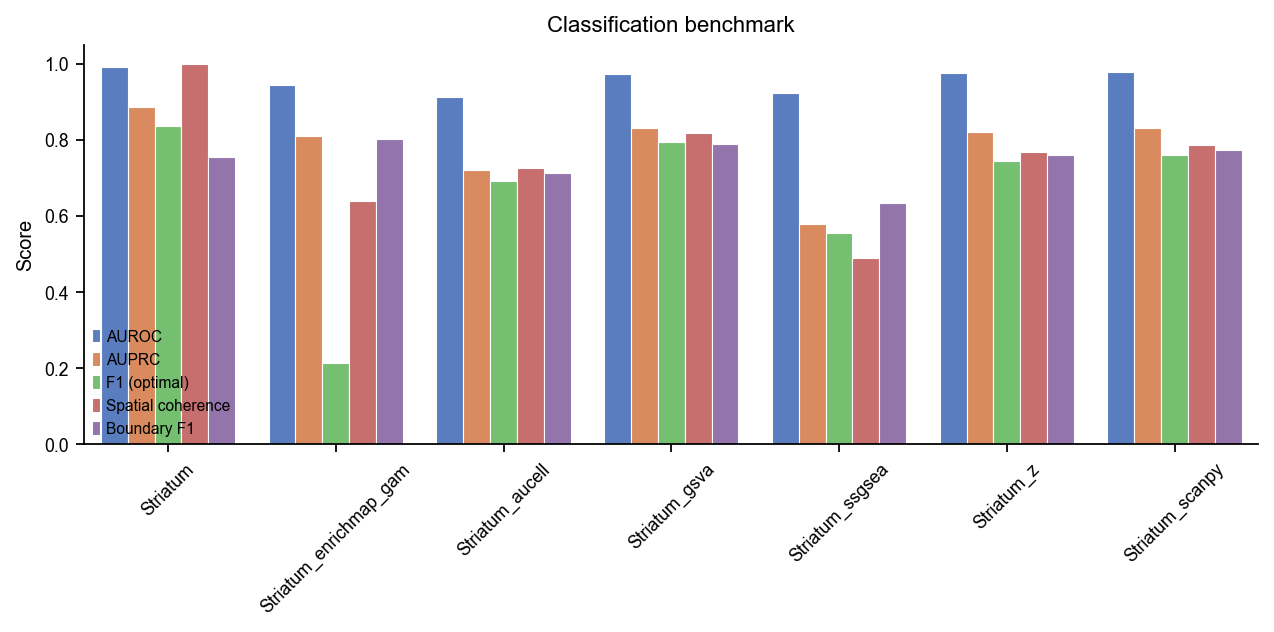

metric                        AUPRC  AUROC  Boundary F1  F1 (optimal)  Spatial coherence
method                                                                                  
Striatum_aucell_score         0.721  0.912        0.713         0.690              0.727
Striatum_enrichmap_gam_score  0.810  0.944        0.802         0.212              0.638
Striatum_gsva_score           0.830  0.974        0.788         0.793              0.818
Striatum_scanpy_score         0.830  0.977        0.772         0.760              0.786
Striatum_score                0.885  0.992        0.754         0.836              1.000
Striatum_ssgsea_score         0.577  0.922        0.632         0.553              0.489
Striatum_z_score              0.821  0.975        0.759         0.743              0.767


In [16]:
# 4. Benchmark 1: Classification
print("BENCHMARK 1: Classification")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    score_keys = [
        f"{ct}_score",                    # EnrichMap (no GAM)
        f"{ct}_enrichmap_gam_score",       # EnrichMap (with GAM)
        f"{ct}_aucell_score",
        f"{ct}_gsva_score",
        f"{ct}_ssgsea_score",
        f"{ct}_z_score",
        f"{ct}_scanpy_score",
    ]
    clf = benchmark_scoring_methods(
        adata,
        score_keys=score_keys,
        label_source="cluster",
        positive_class=ct,
        save=f"figures/benchmark_clf_{ct}.pdf",
    )
    print(
        clf.pivot_table(index="method", columns="metric", values="value")
        .round(3)
        .to_string()
    )

In [ ]:
# 5. Benchmark 2: Within-domain quality
print("BENCHMARK 2: Within-domain quality")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    wd = benchmark_within_domain(
        adata,
        gene_set=signatures_dict[ct],
        scoring_functions=scoring_functions,
        label_source="cluster",
        positive_class=ct,
        save=f"figures/benchmark_within_domain_{ct}.pdf",
    )
    print(
        wd.pivot_table(index="method", columns="metric", values="value")
        .round(3)
        .to_string()
    )

In [ ]:
# 6. Benchmark 3: Noise robustness
print("BENCHMARK 3: Noise robustness")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    noise = benchmark_noise_robustness(
        adata,
        gene_set=signatures_dict[ct],
        scoring_functions=scoring_functions,
        noise_levels=[0.0, 0.5, 1.0, 1.5, 2.0, 3.0],
        n_repeats=5,
        save=f"figures/benchmark_noise_{ct}.pdf",
    )
    at_1x = noise[noise["noise_level"] == 1.0]
    print("Spearman rho at 1x noise:")
    print(at_1x.groupby("method")["correlation"].mean().round(3).to_string())

In [ ]:
clf.to_csv("results/benchmark_classification.csv", index=False)
wd.to_csv("results/benchmark_within_domain.csv", index=False)
noise.to_csv("results/benchmark_noise.csv", index=False)

In [ ]:
# Benchmark 4: Gene weight validation
for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    gw = benchmark_gene_weights(
        adata,
        score_key=ct,
        gene_set=signatures_dict[ct],
        label_source="cluster",
        positive_class=ct,
        save=figure_dir + f"benchmark_weights_{ct}.pdf",
    )
    print(f"Weight-AUROC Spearman rho: {gw.attrs['weight_auroc_rho']:.3f}")
    print(f"p-value: {gw.attrs['weight_auroc_pval']:.2e}")

In [ ]:
# Benchmark 5: Signature contamination robustness
for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    contam = benchmark_contamination(
        adata,
        gene_set=signatures_dict[ct],
        scoring_functions=scoring_functions,
        contamination_fractions=[0.0, 0.25, 0.5, 1.0, 2.0, 4.0],
        n_repeats=10,
        save=f"figures/benchmark_contamination_{ct}.pdf",
    )
    # Summary at 2× contamination (2/3 of genes are noise)
    at_2x = contam[contam["contamination"] == 2.0]
    print("Spearman rho at 2x contamination:")
    print(at_2x.groupby("method")["correlation"].mean().round(3).to_string())

In [ ]:
# Benchmark 6: Neighbourhood enrichment concordance
for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    sc_result = benchmark_spatial_concordance(
        adata,
        score_keys=[
            f"{ct}_score", # EnrichMap (no GAM)
            f"{ct}_enrichmap_gam_score", # EnrichMap (with GAM)
            f"{ct}_aucell_score",
            f"{ct}_gsva_score",
            f"{ct}_ssgsea_score",
            f"{ct}_z_score",
            f"{ct}_scanpy_score",
        ],
        label_source="cluster",
        positive_class=ct,
        n_neighbors=6,
        smoothing_iterations=list(range(1, 11)),
        save=figure_dir + f"benchmark_concordance_{ct}.pdf",
    )
    print(
        sc_result.pivot_table(
            index="method",
            columns="smoothing_iter",
            values="concordance",
        )
        .round(3)
        .to_string()
    )

In [ ]:
# Benchmark 7: KS statistic (distribution separation)
print("BENCHMARK 7: KS statistic")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    score_keys = [
        f"{ct}_score", # EnrichMap (no GAM)
        f"{ct}_enrichmap_gam_score", # EnrichMap (with GAM)
        f"{ct}_aucell_score",
        f"{ct}_gsva_score",
        f"{ct}_ssgsea_score",
        f"{ct}_z_score",
        f"{ct}_scanpy_score",
    ]
    ks_result = benchmark_ks_statistic(
        adata,
        score_keys=score_keys,
        label_source="cluster",
        positive_class=ct,
        save=figure_dir + f"benchmark_ks_{ct}.pdf",
    )
    print(ks_result.to_string(index=False))

In [ ]:
# Benchmark 8: Rank consistency across methods
print("BENCHMARK 8: Rank consistency")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")
    score_keys = [
        f"{ct}_score", # EnrichMap (no GAM)
        f"{ct}_enrichmap_gam_score", # EnrichMap (with GAM)
        f"{ct}_aucell_score",
        f"{ct}_gsva_score",
        f"{ct}_ssgsea_score",
        f"{ct}_z_score",
        f"{ct}_scanpy_score",
    ]
    rank_result = benchmark_rank_consistency(
        adata,
        score_keys=score_keys,
        save=figure_dir + f"benchmark_rank_consistency_{ct}.pdf",
    )
    print(rank_result.round(3).to_string())

In [ ]:
# Benchmark 9: Spatial SSIM (within-domain micro-structure preservation)
print("BENCHMARK 9: Spatial SSIM")

for ct in [cell_type_1, cell_type_2]:
    print(f"\n {ct}:")

    ssim_result = benchmark_spatial_ssim(
        adata,
        gene_set=signatures_dict[ct],
        scoring_functions=scoring_functions,
        label_source="cluster",
        positive_class=ct,
        n_neighbors=6,
        mode="within_domain",
        save=figure_dir + f"benchmark_ssim_{ct}.pdf",
    )

    # Print mean SSIM per method
    ssim_means = ssim_result[ssim_result["gene"] == "mean"][
        ["method", "ssim"]
    ].sort_values("ssim", ascending=False)
    print(ssim_means.to_string(index=False))

In [ ]:
# Plot F1 and Spatial coherence in two separate panels from benchmark_classification.csv
clf_results = pd.read_csv("results/benchmark_classification.csv")

# Clean method names: strip cell-type prefix
name_map = {
    "score":               "EnrichMap",
    "enrichmap_gam_score": "EnrichMap (GAM)",
    "aucell_score":        "AUCell",
    "gsva_score":          "GSVA",
    "ssgsea_score":        "ssGSEA",
    "z_score":             "z-score",
    "scanpy_score":        "scanpy",
}
def clean_method(m):
    parts = m.split("_", 1)
    suffix = parts[1] if len(parts) > 1 else parts[0]
    return name_map.get(suffix, suffix)

clf_results["method_label"] = clf_results["method"].apply(clean_method)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["F1 (optimal)", "Spatial coherence"]):
    sub = clf_results[clf_results["metric"] == metric].sort_values("value", ascending=False)
    ax.bar(
        sub["method_label"], sub["value"],
        color=sns.color_palette("tab10", len(sub)),
    )
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

plt.suptitle("Classification performance across methods", y=1.02)
plt.tight_layout()
plt.savefig("figures/benchmark_f1_spatial_coherence_barplot.pdf", bbox_inches="tight")
plt.show()